# 01 — Exploratory Data Analysis
## NASA PCoE Li-ion Battery Dataset

**Objective:** Comprehensive statistical and visual exploration of the cleaned dataset, covering:
- Dataset overview and battery group statistics
- Capacity fade curves across all batteries (MATLAB-style)
- Temperature-dependent degradation analysis
- Impedance evolution (Re, Rct)
- Feature correlation structure
- SOH distribution and EOL threshold analysis
- 3D voltage surface visualization

**Dataset:** 36 Li-ion 18650 cells (B0005–B0056, excluding B0049–B0052), ~7,500 charge/discharge/impedance cycles, nominal capacity 2.0 Ah.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

from src.data.loader import (
    load_metadata, load_discharge_capacities, load_impedance_scalars,
    load_cycle_csv, get_battery_ids, get_eol_threshold, BATTERY_EOL_MAP,
    EXCLUDED_BATTERIES, NOMINAL_CAPACITY_AH,
)
from src.utils.plotting import save_fig
from src.utils.config import FIGURES_DIR, FIG_DPI

# Research-grade style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.4)
matplotlib.rcParams.update({
    "figure.dpi": FIG_DPI,
    "savefig.dpi": FIG_DPI,
    "font.family": "serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})
print("Setup complete.")

Setup complete.


## 1. Dataset Overview

Load metadata and compute battery-level and group-level summary statistics.

In [2]:
meta = load_metadata(exclude_corrupt=True, parse_dates=True)
print(f"Total cycle records: {len(meta):,}")
print(f"Cycle types: {meta['type'].value_counts().to_dict()}")
print(f"Unique batteries: {meta['battery_id'].nunique()}")
print(f"Temperature groups: {sorted(meta['ambient_temperature'].unique())}")

# Per-battery summary
battery_summary = meta.groupby("battery_id").agg(
    n_cycles=("test_id", "count"),
    n_charge=("type", lambda x: (x == "charge").sum()),
    n_discharge=("type", lambda x: (x == "discharge").sum()),
    n_impedance=("type", lambda x: (x == "impedance").sum()),
    ambient_temp=("ambient_temperature", "first"),
).reset_index()
battery_summary["eol_threshold"] = battery_summary["battery_id"].map(BATTERY_EOL_MAP)
display(battery_summary)

Total cycle records: 7,317
Cycle types: {'charge': 2715, 'discharge': 2694, 'impedance': 1908}
Unique batteries: 30
Temperature groups: [np.int64(4), np.int64(22), np.int64(24), np.int64(43), np.int64(44)]


,battery_id,n_cycles,n_charge,n_discharge,n_impedance,ambient_temp,eol_threshold
0,B0005,616,170,168,278,24,1.4
1,B0006,616,170,168,278,24,1.4
2,B0007,616,170,168,278,24,1.4
3,B0018,319,134,132,53,24,1.4
4,B0025,80,31,28,21,24,1.4
5,B0026,80,31,28,21,24,1.4
6,B0027,80,31,28,21,24,1.4
7,B0028,80,31,28,21,24,1.4
8,B0029,97,40,40,17,43,1.4
9,B0030,97,40,40,17,43,1.4


In [3]:
# Group batteries by temperature and display counts
group_table = battery_summary.groupby("ambient_temp").agg(
    n_batteries=("battery_id", "count"),
    total_cycles=("n_cycles", "sum"),
    avg_discharge_cycles=("n_discharge", "mean"),
    batteries=("battery_id", lambda x: ", ".join(sorted(x))),
).reset_index()
display(group_table)

,ambient_temp,n_batteries,total_cycles,avg_discharge_cycles,batteries
0,4,9,1793,79.777778,"B0041, B0045, B0046, B0047, B0048, B0053, B005..."
1,22,3,825,112.000000,"B0042, B0043, B0044"
2,24,14,4311,105.714286,"B0005, B0006, B0007, B0018, B0025, B0026, B002..."
3,43,4,388,40.000000,"B0029, B0030, B0031, B0032"


## 2. Capacity Fade Curves

The primary degradation signature: discharge capacity (Ah) vs. cycle number for each battery. This is the most important plot — it shows how different operating conditions (temperature, discharge current, cutoff voltage) affect battery lifespan.

Discharge capacity records: 2,678
Capacity range: [0.0441, 2.4441] Ah


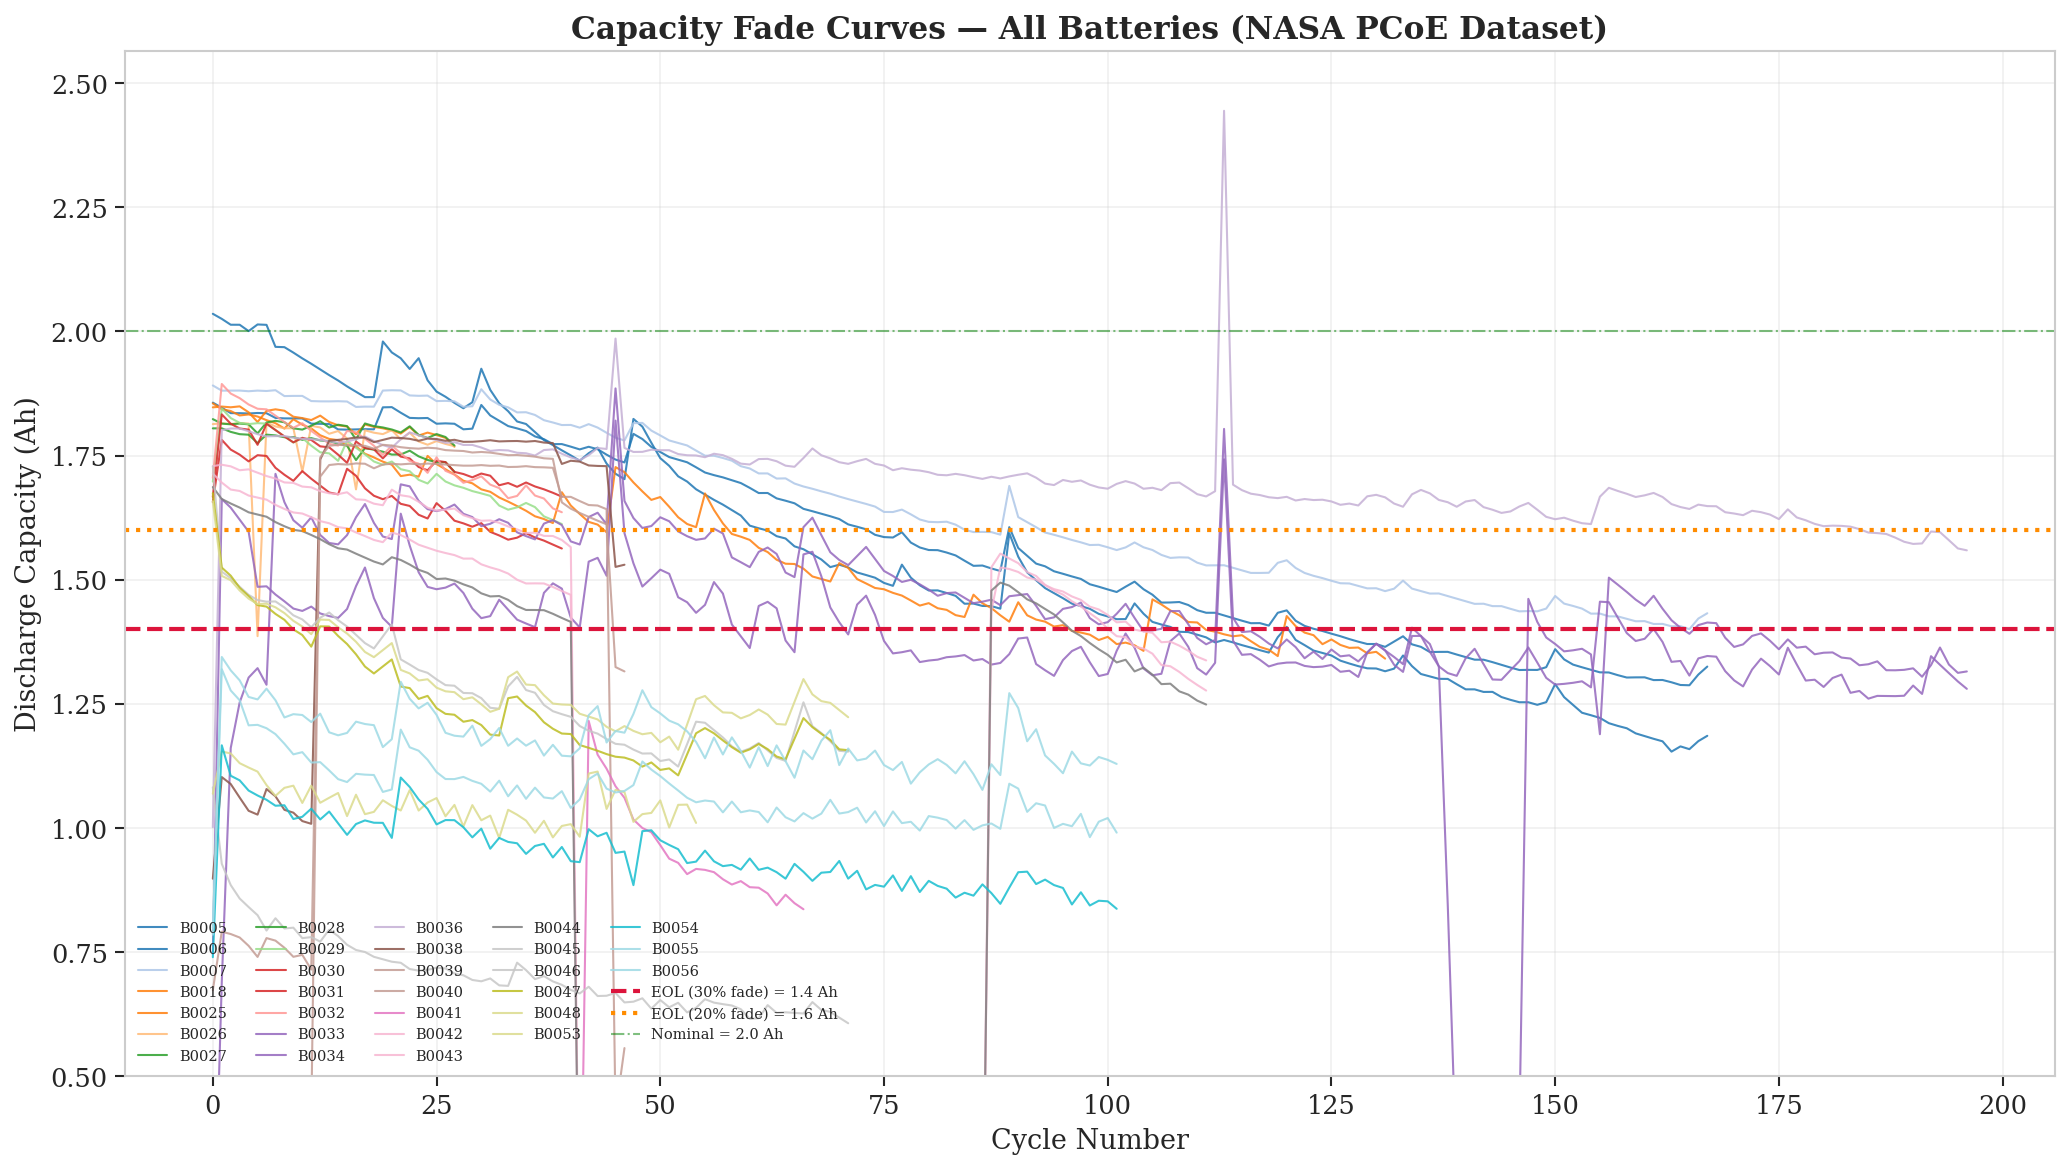

In [4]:
cap_df = load_discharge_capacities(exclude_corrupt=True, drop_zero=True)
print(f"Discharge capacity records: {len(cap_df):,}")
print(f"Capacity range: [{cap_df['Capacity'].min():.4f}, {cap_df['Capacity'].max():.4f}] Ah")

# MATLAB-style capacity fade plot — all batteries
fig, ax = plt.subplots(figsize=(14, 8))
batteries = sorted(cap_df["battery_id"].unique())
cmap = plt.cm.get_cmap("tab20", len(batteries))

for i, bid in enumerate(batteries):
    sub = cap_df[cap_df["battery_id"] == bid]
    ax.plot(sub["cycle_number"], sub["Capacity"], label=bid, color=cmap(i), linewidth=1.0, alpha=0.85)

ax.axhline(y=1.4, color="crimson", linestyle="--", linewidth=2, label="EOL (30% fade) = 1.4 Ah")
ax.axhline(y=1.6, color="darkorange", linestyle=":", linewidth=2, label="EOL (20% fade) = 1.6 Ah")
ax.axhline(y=2.0, color="green", linestyle="-.", linewidth=1, alpha=0.5, label="Nominal = 2.0 Ah")

ax.set_xlabel("Cycle Number", fontsize=13)
ax.set_ylabel("Discharge Capacity (Ah)", fontsize=13)
ax.set_title("Capacity Fade Curves — All Batteries (NASA PCoE Dataset)", fontsize=15, fontweight="bold")
ax.legend(fontsize=7, ncol=5, loc="lower left", framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0.5)
save_fig(fig, "capacity_fade_all_batteries")
plt.show()

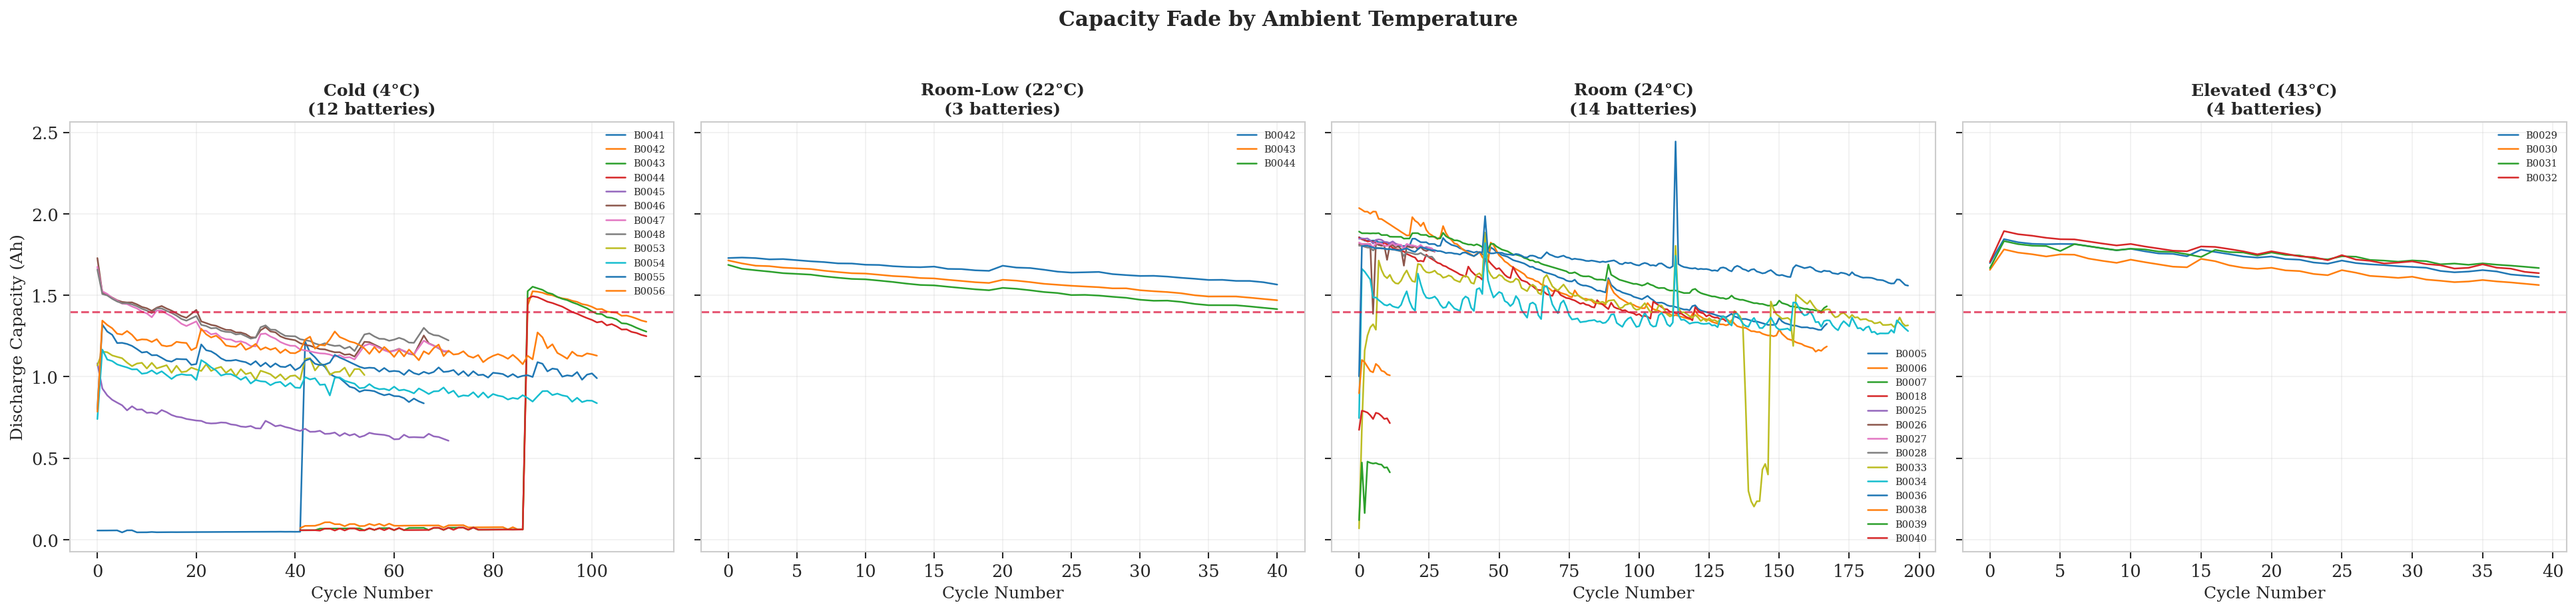

Temperature distribution: {4: 12, 22: 3, 24: 14, 43: 4, 44: 3}


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(26, 6), sharey=True)
temp_groups = {4: "Cold (4°C)", 22: "Room-Low (22°C)", 24: "Room (24°C)", 43: "Elevated (43°C)"}

for ax, (temp, label) in zip(axes, temp_groups.items()):
    subset = cap_df[cap_df["ambient_temperature"] == temp]
    for bid in sorted(subset["battery_id"].unique()):
        sub = subset[subset["battery_id"] == bid]
        ax.plot(sub["cycle_number"], sub["Capacity"], label=bid, linewidth=1.2)
    ax.axhline(y=1.4, color="crimson", linestyle="--", linewidth=1.5, alpha=0.7)
    ax.set_title(f"{label}\n({len(subset['battery_id'].unique())} batteries)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Cycle Number")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

axes[0].set_ylabel("Discharge Capacity (Ah)")
fig.suptitle("Capacity Fade by Ambient Temperature", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "capacity_fade_by_temperature")
plt.show()
print(f"Temperature distribution: {cap_df.groupby('ambient_temperature')['battery_id'].nunique().to_dict()}")

## 3. Capacity Distribution Analysis

Violin/box plots showing how ambient temperature affects the overall capacity distribution. Higher temperatures (43°C) accelerate degradation, while cold operation (4°C) shows different degradation patterns.

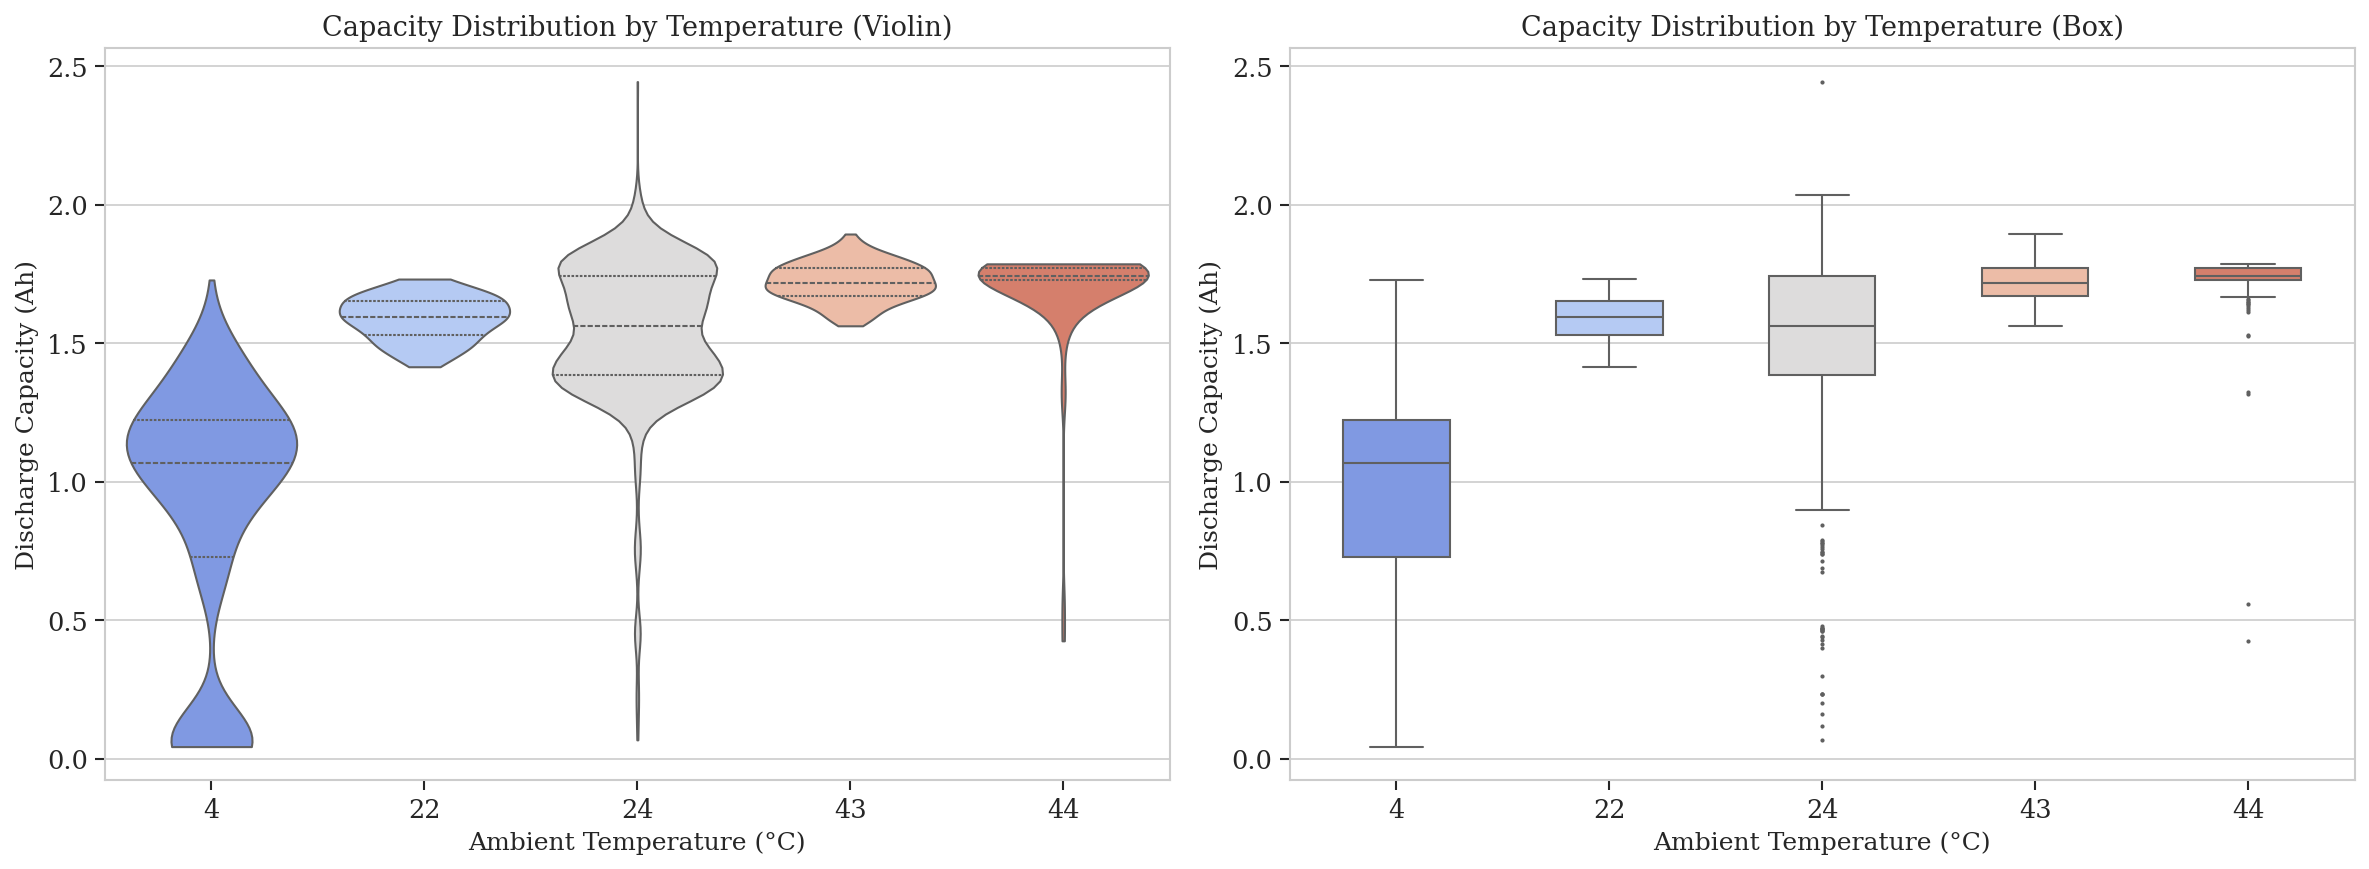

                      count    mean     std     min     25%     50%     75%  \
ambient_temperature                                                           
4                     918.0  0.9145  0.4609  0.0441  0.7294  1.0663  1.2223   
22                    120.0  1.5900  0.0797  1.4150  1.5309  1.5951  1.6531   
24                   1375.0  1.5407  0.2594  0.0684  1.3866  1.5613  1.7433   
43                    160.0  1.7212  0.0699  1.5628  1.6712  1.7189  1.7704   
44                    105.0  1.7053  0.1865  0.4258  1.7286  1.7433  1.7716   

                        max  
ambient_temperature          
4                    1.7282  
22                   1.7315  
24                   2.4441  
43                   1.8940  
44                   1.7864  


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violin plot
sns.violinplot(data=cap_df, x="ambient_temperature", y="Capacity", ax=axes[0],
               inner="quartile", palette="coolwarm", cut=0)
axes[0].set_title("Capacity Distribution by Temperature (Violin)", fontsize=13)
axes[0].set_xlabel("Ambient Temperature (°C)")
axes[0].set_ylabel("Discharge Capacity (Ah)")

# Box plot with swarm overlay
sns.boxplot(data=cap_df, x="ambient_temperature", y="Capacity", ax=axes[1],
            palette="coolwarm", width=0.5, fliersize=1)
axes[1].set_title("Capacity Distribution by Temperature (Box)", fontsize=13)
axes[1].set_xlabel("Ambient Temperature (°C)")
axes[1].set_ylabel("Discharge Capacity (Ah)")

plt.tight_layout()
save_fig(fig, "capacity_distribution_by_temp")
plt.show()

# Statistics per temperature group
print(cap_df.groupby("ambient_temperature")["Capacity"].describe().round(4))

## 4. Impedance Evolution

Electrolyte resistance (Re) and charge-transfer resistance (Rct) measured via EIS increase as the battery degrades. These are key health indicators.

Impedance records: 1,908


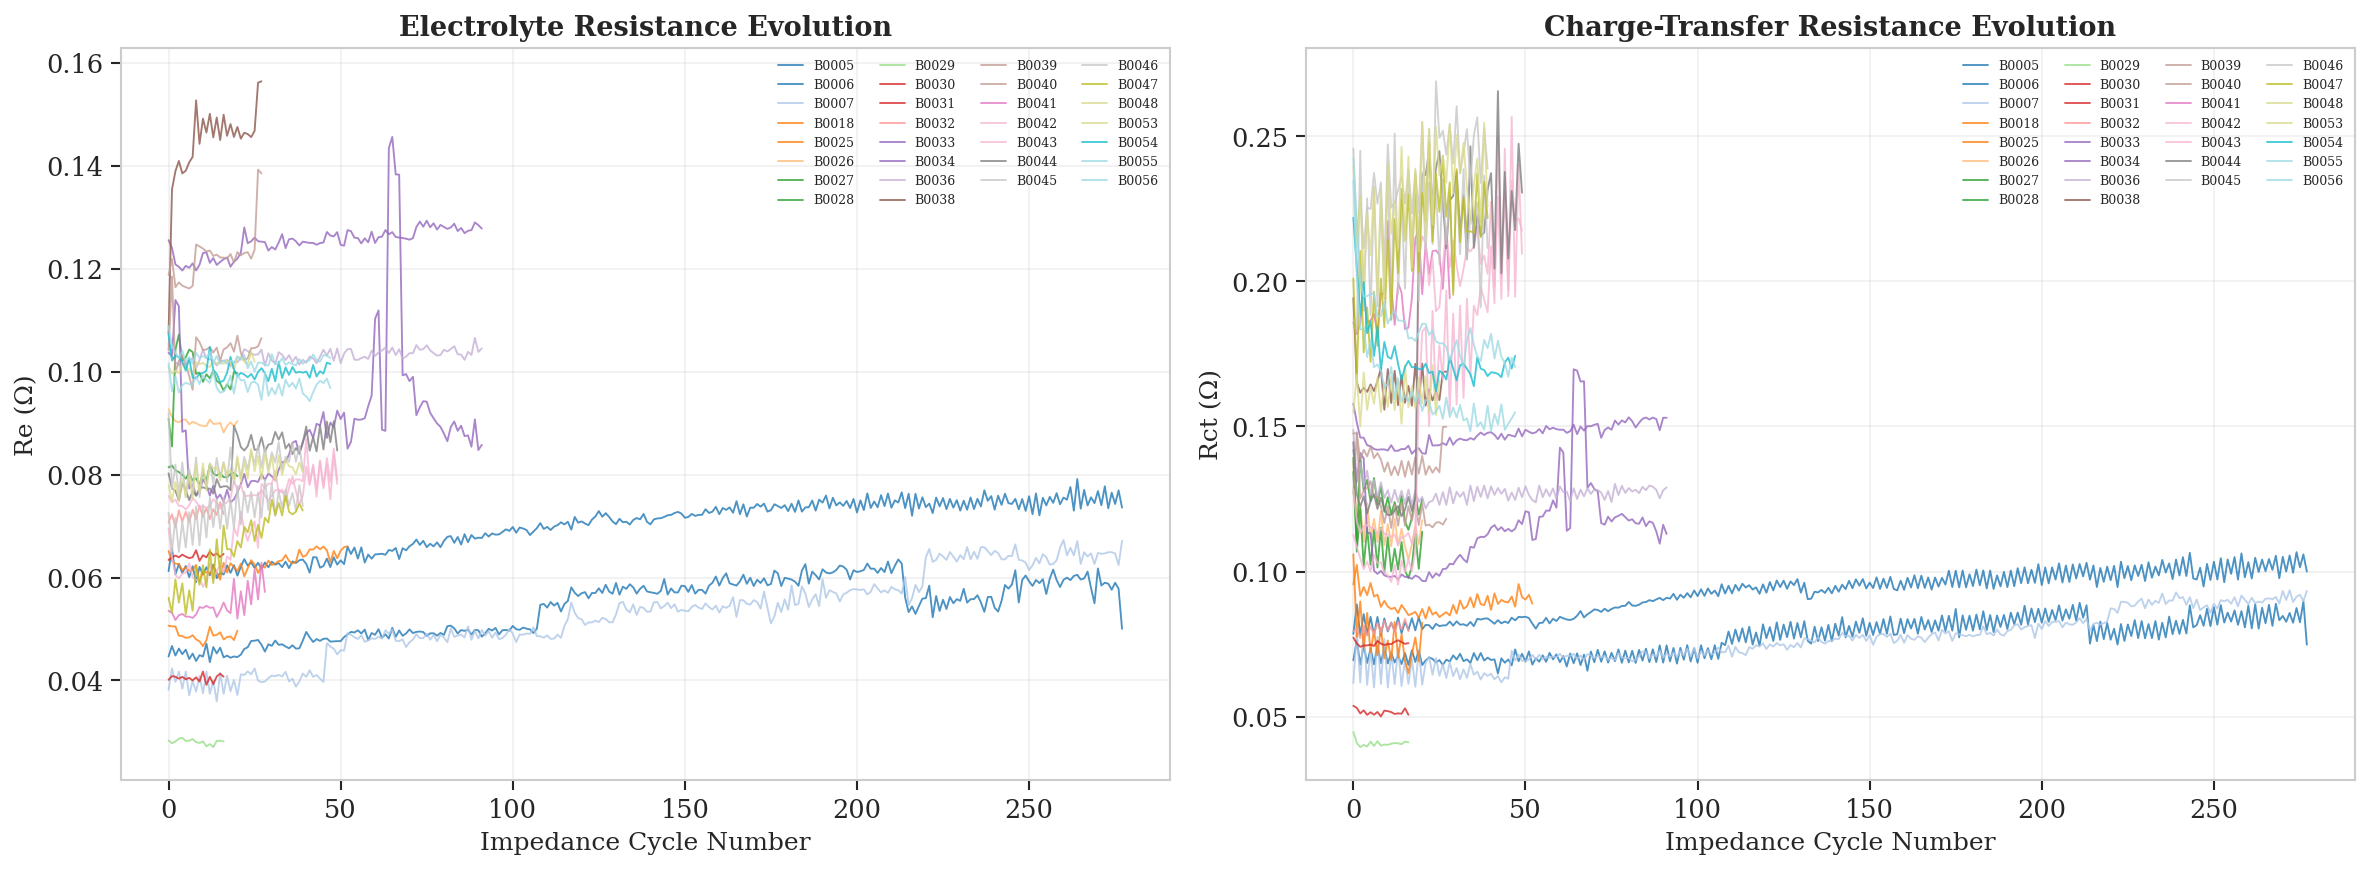

In [7]:
imp_df = load_impedance_scalars(exclude_corrupt=True)
print(f"Impedance records: {len(imp_df):,}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
batteries_with_imp = sorted(imp_df["battery_id"].unique())
cmap2 = plt.cm.get_cmap("tab20", len(batteries_with_imp))

for i, bid in enumerate(batteries_with_imp):
    sub = imp_df[imp_df["battery_id"] == bid]
    axes[0].plot(sub["cycle_number"], sub["Re"], label=bid, color=cmap2(i), linewidth=0.9, alpha=0.8)
    axes[1].plot(sub["cycle_number"], sub["Rct"], label=bid, color=cmap2(i), linewidth=0.9, alpha=0.8)

axes[0].set_xlabel("Impedance Cycle Number")
axes[0].set_ylabel("Re (Ω)")
axes[0].set_title("Electrolyte Resistance Evolution", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=6, ncol=4)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Impedance Cycle Number")
axes[1].set_ylabel("Rct (Ω)")
axes[1].set_title("Charge-Transfer Resistance Evolution", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=6, ncol=4)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, "impedance_evolution")
plt.show()

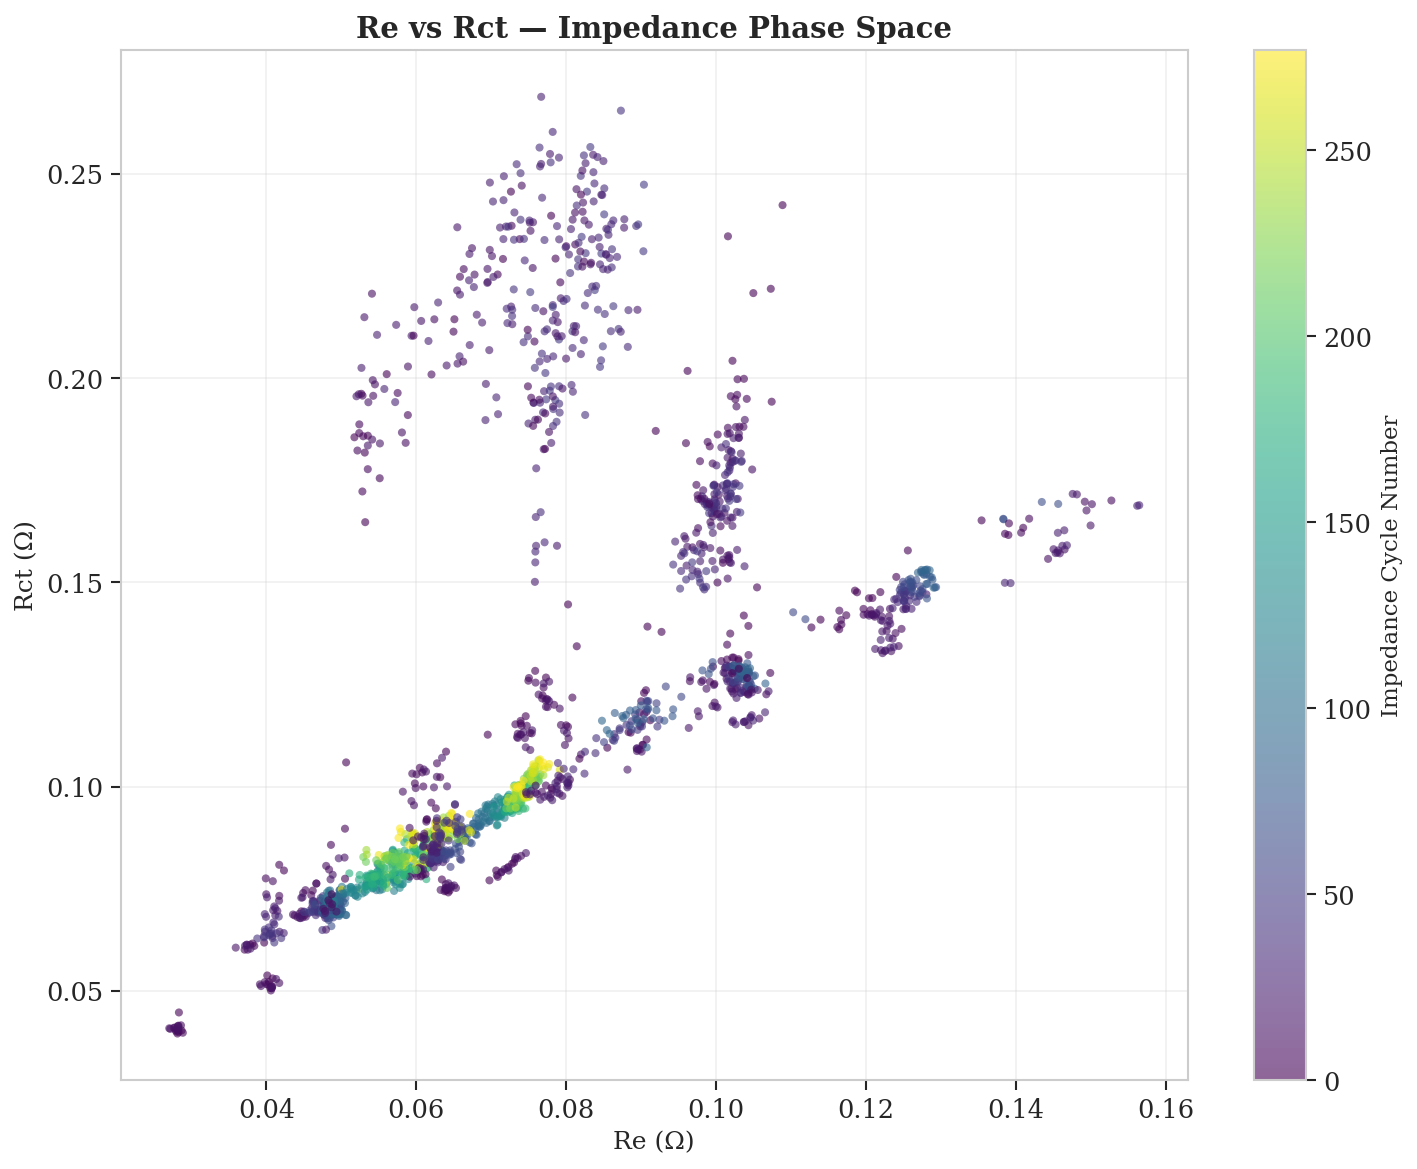

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(imp_df["Re"], imp_df["Rct"], c=imp_df["cycle_number"],
                     cmap="viridis", alpha=0.6, s=15, edgecolors="none")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Impedance Cycle Number", fontsize=11)
ax.set_xlabel("Re (Ω)", fontsize=12)
ax.set_ylabel("Rct (Ω)", fontsize=12)
ax.set_title("Re vs Rct — Impedance Phase Space", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
save_fig(fig, "re_vs_rct_scatter")
plt.show()

## 5. SOH Distribution

State of Health (SOH) = (Measured Capacity / Nominal Capacity) × 100%. We examine the overall distribution and mark the EOL thresholds.

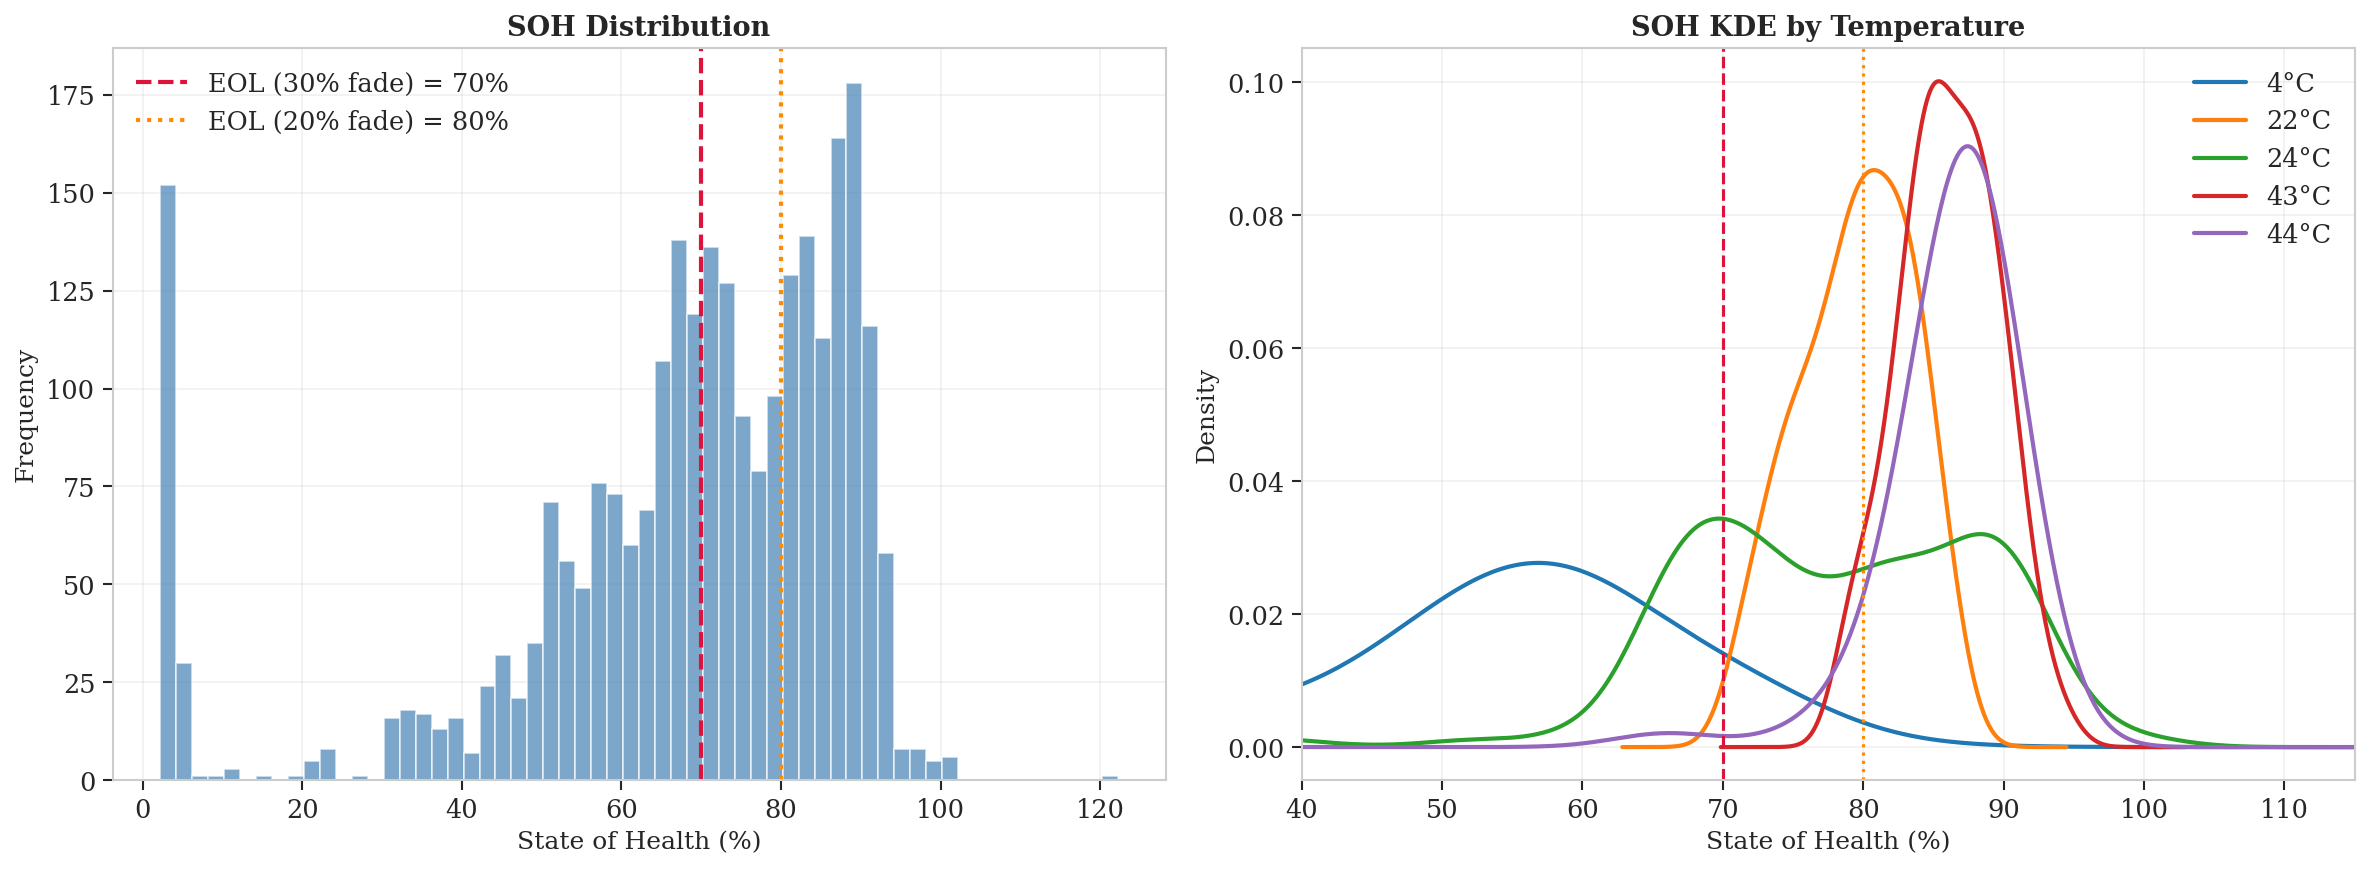

In [9]:
cap_df["SoH"] = (cap_df["Capacity"] / NOMINAL_CAPACITY_AH) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(cap_df["SoH"], bins=60, color="steelblue", alpha=0.7, edgecolor="white")
axes[0].axvline(x=70, color="crimson", linestyle="--", linewidth=2, label="EOL (30% fade) = 70%")
axes[0].axvline(x=80, color="darkorange", linestyle=":", linewidth=2, label="EOL (20% fade) = 80%")
axes[0].set_xlabel("State of Health (%)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("SOH Distribution", fontsize=13, fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# KDE per temperature
for temp in sorted(cap_df["ambient_temperature"].unique()):
    sub = cap_df[cap_df["ambient_temperature"] == temp]
    sub["SoH"].plot.kde(ax=axes[1], label=f"{temp}°C", linewidth=2)
axes[1].axvline(x=70, color="crimson", linestyle="--", linewidth=1.5)
axes[1].axvline(x=80, color="darkorange", linestyle=":", linewidth=1.5)
axes[1].set_xlabel("State of Health (%)")
axes[1].set_title("SOH KDE by Temperature", fontsize=13, fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(40, 115)

plt.tight_layout()
save_fig(fig, "soh_distribution")
plt.show()

## 6. Voltage Surface Visualization (3D)

3D surface plot of discharge voltage as a function of time (within cycle) and cycle number, for a representative battery. This reveals how the voltage plateau drops and shortens as the battery degrades.

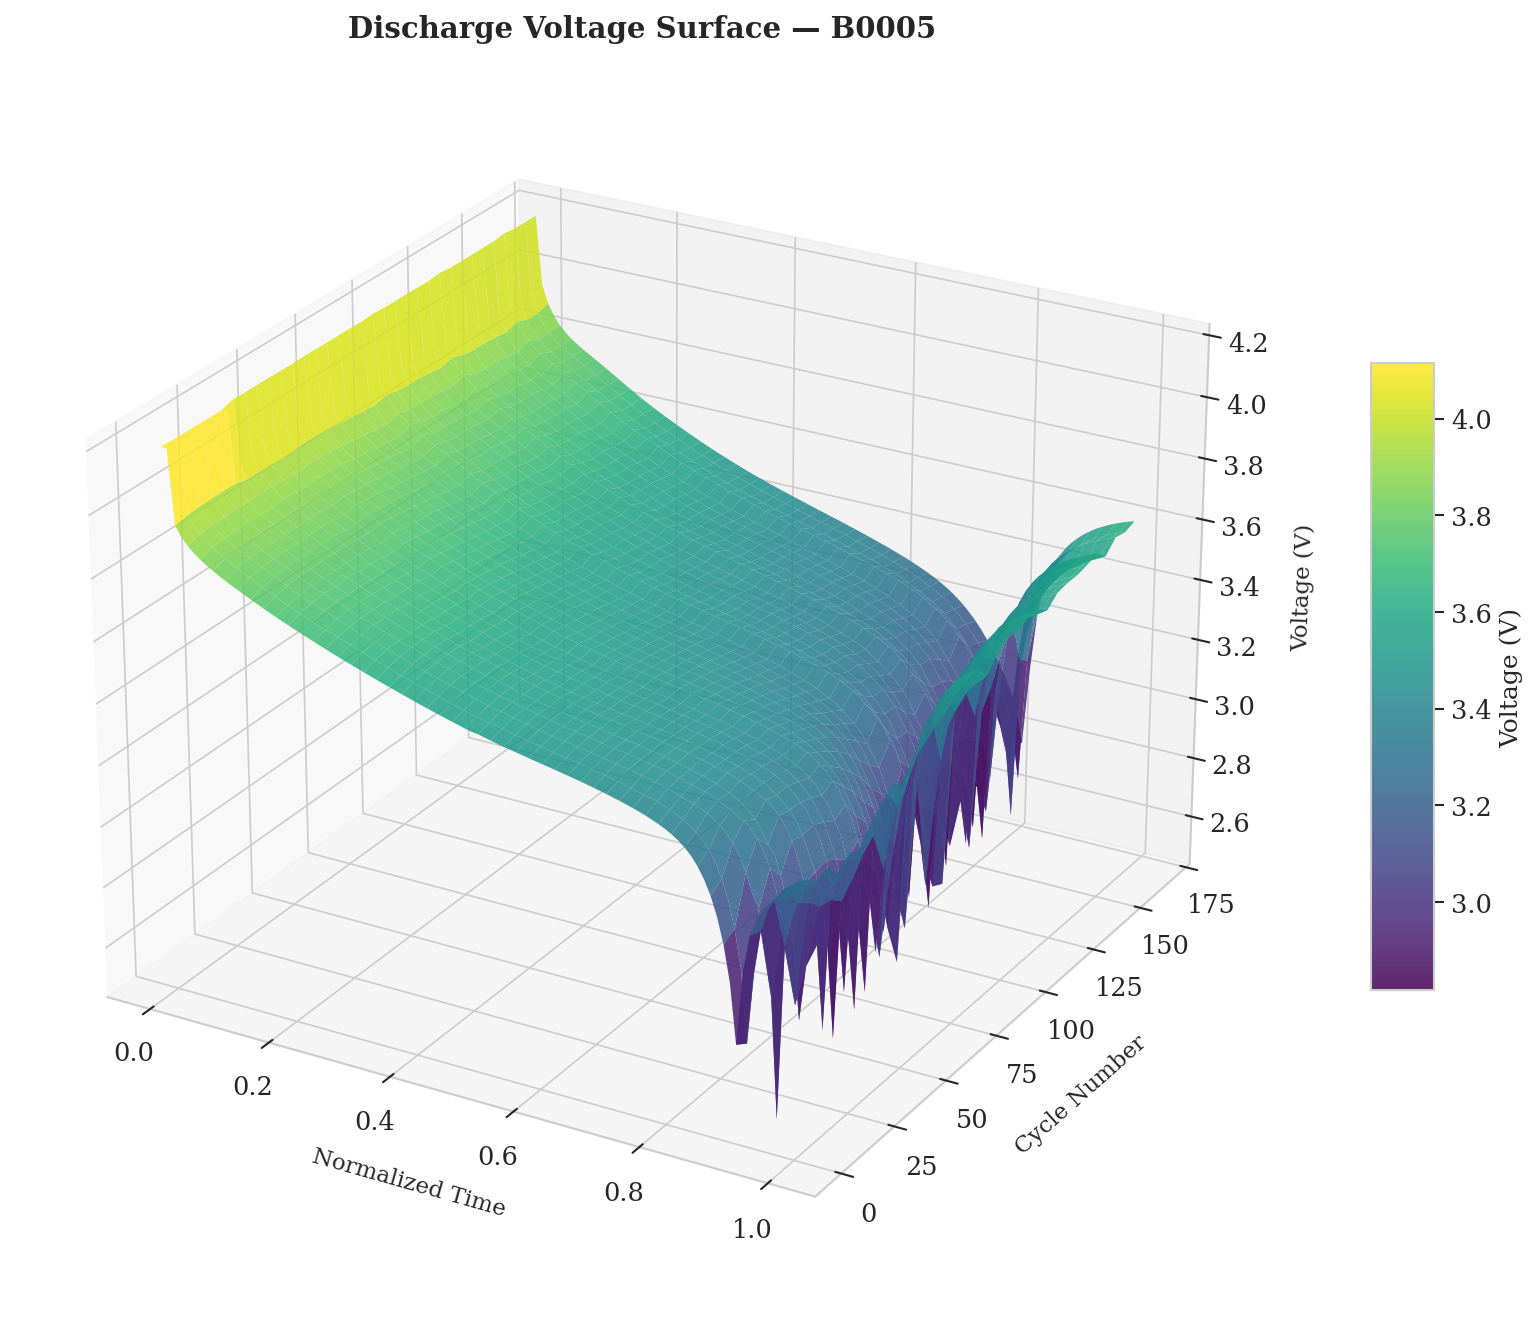

In [10]:
from src.data.loader import load_metadata, load_cycle_csv

# Pick a battery with many cycles
meta = load_metadata(exclude_corrupt=True, parse_dates=False)
bid_target = "B0005"
dis_meta = meta[(meta["battery_id"] == bid_target) & (meta["type"] == "discharge")].copy()
dis_meta = dis_meta.sort_values("test_id").reset_index(drop=True)
dis_meta["cycle_number"] = range(len(dis_meta))

# Sample every 5th cycle to keep manageable
sample_cycles = dis_meta.iloc[::5]
n_time_points = 100  # Resample each cycle to fixed length

voltage_matrix = []
cycle_nums = []
for _, row in sample_cycles.iterrows():
    try:
        cdf = load_cycle_csv(row["uid"])
        v = cdf["Voltage_measured"].values
        # Resample to fixed length
        indices = np.linspace(0, len(v) - 1, n_time_points).astype(int)
        voltage_matrix.append(v[indices])
        cycle_nums.append(row["cycle_number"])
    except Exception:
        continue

voltage_matrix = np.array(voltage_matrix)
time_axis = np.linspace(0, 1, n_time_points)

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection="3d")
T, C = np.meshgrid(time_axis, cycle_nums)
surf = ax.plot_surface(T, C, voltage_matrix, cmap="viridis", alpha=0.85,
                       edgecolor="none", antialiased=True)
ax.set_xlabel("Normalized Time", fontsize=11, labelpad=10)
ax.set_ylabel("Cycle Number", fontsize=11, labelpad=10)
ax.set_zlabel("Voltage (V)", fontsize=11, labelpad=10)
ax.set_title(f"Discharge Voltage Surface — {bid_target}", fontsize=14, fontweight="bold")
fig.colorbar(surf, shrink=0.5, aspect=10, label="Voltage (V)")
ax.view_init(elev=25, azim=-60)
save_fig(fig, "voltage_surface_3d")
plt.show()

In [11]:
# Interactive 3D with Plotly
fig_3d = go.Figure(data=[go.Surface(
    x=time_axis, y=cycle_nums, z=voltage_matrix,
    colorscale="Viridis", showscale=True,
    colorbar=dict(title="Voltage (V)"),
)])
fig_3d.update_layout(
    title=f"Interactive Discharge Voltage Surface — {bid_target}",
    scene=dict(
        xaxis_title="Normalized Time",
        yaxis_title="Cycle Number",
        zaxis_title="Voltage (V)",
    ),
    width=900, height=700,
)
fig_3d.write_html(str(FIGURES_DIR / "voltage_surface_3d_interactive.html"))
fig_3d.show()

## 7. Interactive Capacity Fade (Plotly)

Hover-enabled capacity fade curves for all batteries with temperature coloring.

In [12]:
fig_cap = px.line(
    cap_df, x="cycle_number", y="Capacity",
    color="battery_id", line_group="battery_id",
    hover_data=["ambient_temperature", "SoH"],
    title="Interactive Capacity Fade — All Batteries",
    labels={"cycle_number": "Cycle Number", "Capacity": "Discharge Capacity (Ah)"},
)
fig_cap.add_hline(y=1.4, line_dash="dash", line_color="red", annotation_text="EOL (30%)")
fig_cap.add_hline(y=1.6, line_dash="dot", line_color="orange", annotation_text="EOL (20%)")
fig_cap.update_layout(width=1100, height=600)
fig_cap.write_html(str(FIGURES_DIR / "capacity_fade_interactive.html"))
fig_cap.show()

## 8. Summary Statistics

Key dataset statistics for the research paper.

In [13]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total batteries:           {cap_df['battery_id'].nunique()}")
print(f"Total discharge cycles:    {len(cap_df):,}")
print(f"Nominal capacity:          {NOMINAL_CAPACITY_AH} Ah")
print(f"Capacity range:            [{cap_df['Capacity'].min():.4f}, {cap_df['Capacity'].max():.4f}] Ah")
print(f"SOH range:                 [{cap_df['SoH'].min():.1f}%, {cap_df['SoH'].max():.1f}%]")
print(f"Temperature groups:        {sorted(cap_df['ambient_temperature'].unique())} °C")
print(f"Mean cycles per battery:   {cap_df.groupby('battery_id')['cycle_number'].max().mean():.0f}")
print(f"Max cycles (any battery):  {cap_df['cycle_number'].max()}")
n_eol = cap_df.groupby("battery_id").apply(lambda g: (g["Capacity"] < get_eol_threshold(g.name)).any()).sum()
print(f"Batteries reaching EOL:    {n_eol} / {cap_df['battery_id'].nunique()}")
print("=" * 60)

DATASET SUMMARY
Total batteries:           30
Total discharge cycles:    2,678
Nominal capacity:          2.0 Ah
Capacity range:            [0.0441, 2.4441] Ah
SOH range:                 [2.2%, 122.2%]
Temperature groups:        [np.int64(4), np.int64(22), np.int64(24), np.int64(43), np.int64(44)] °C
Mean cycles per battery:   89
Max cycles (any battery):  196
Batteries reaching EOL:    22 / 30
